# Tutorial 13: Rendezvous & CW Equation Tracking

This tutorial covers **Relative Orbital Mechanics** and relative targeting using the Clohessy-Wiltshire (CW) equations and absolute targeting via Lambert's problem.

---

## 1. Theory Prerequisite

### 1.1 Clohessy-Wiltshire (Hill's) Equations
Describes the relative motion of a **Chaser** spacecraft with respect to a **Target** spacecraft in a circular orbit.

- **Frame**: Local-Vertical Local-Horizontal (LVLH)
    - $x$: Radial (Away from center)
    - $y$: Along-track (Velocity direction)
    - $z$: Cross-track (Angular momentum)

State yields analytical equations of motion when relative distance is $r \ll r_{target}$.

### 1.2 Lambert's Problem
Given initial position $r_1$, final position $r_2$, and a time-of-flight $\Delta t$, determine the initial velocity $v_1$ and final velocity $v_2$ required to connect the two points under Keplerian dynamics.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from opengnc.guidance.rendezvous import cw_equations, cw_targeting, solve_lambert

print("Imports successful.")

Imports successful.


## 2. Demonstration: Clohessy-Wiltshire Propagation

We simulate a chaser starting 1 km behind and 500m above the target with some relative velocity offset.

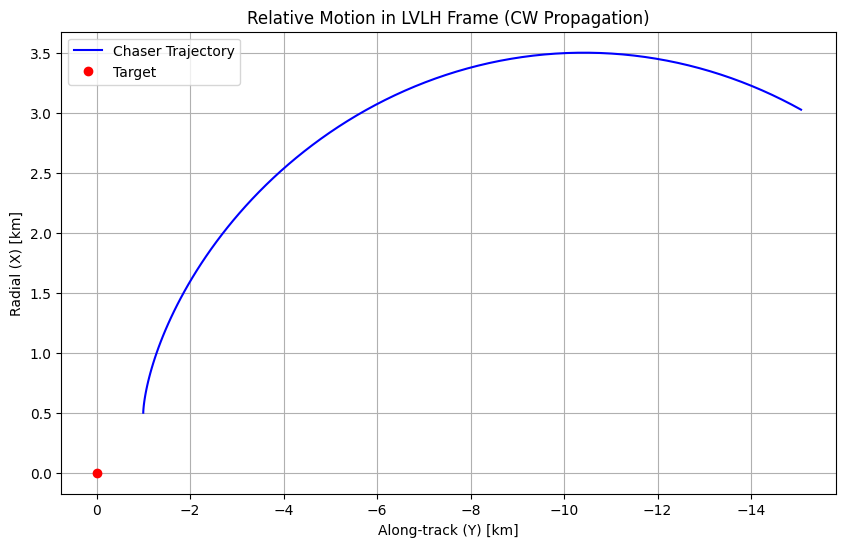

In [7]:
n_orbit = 0.0011  # Mean motion (rad/s) for a standard LEO orbit
r0 = np.array([0.5, -1.0, 0.0])  # [x, y, z] in km (500m radial node higher, 1km behind)
v0 = np.array([0.0, 0.0, 0.0])   # stationary relative to target initially

time = np.linspace(0, 3600, 100)  # 1 hour simulation
history_r = []

for t in time:
    r_t, v_t = cw_equations(r0, v0, n_orbit, t)
    history_r.append(r_t)
    
history_r = np.array(history_r)

plt.figure(figsize=(10, 6))
plt.plot(history_r[:, 1], history_r[:, 0], 'b-', label='Chaser Trajectory')
plt.plot(0, 0, 'ro', label='Target')
plt.xlabel('Along-track (Y) [km]')
plt.ylabel('Radial (X) [km]')
plt.title('Relative Motion in LVLH Frame (CW Propagation)')
plt.gca().invert_xaxis()  # Target is ahead on negative Y for chaser scaling commonly
plt.legend()
plt.grid(True)
plt.show()

## 3. CW Targeting (Rendezvous)

Now we calculate an impulse to rendezvous with the target ($r_{target} = [0, 0, 0]$) in 30 minutes.

Initial Relative Position: [ 0.5 -1.   0. ] km
Required Burn Velocity v0: [-0.00111513 -0.00065579  0.        ] km/s
Delta-V Needed: 0.001294 km/s

Position at t=1800.0s: [2.22044605e-16 0.00000000e+00 0.00000000e+00] km (Should be near [0,0,0])


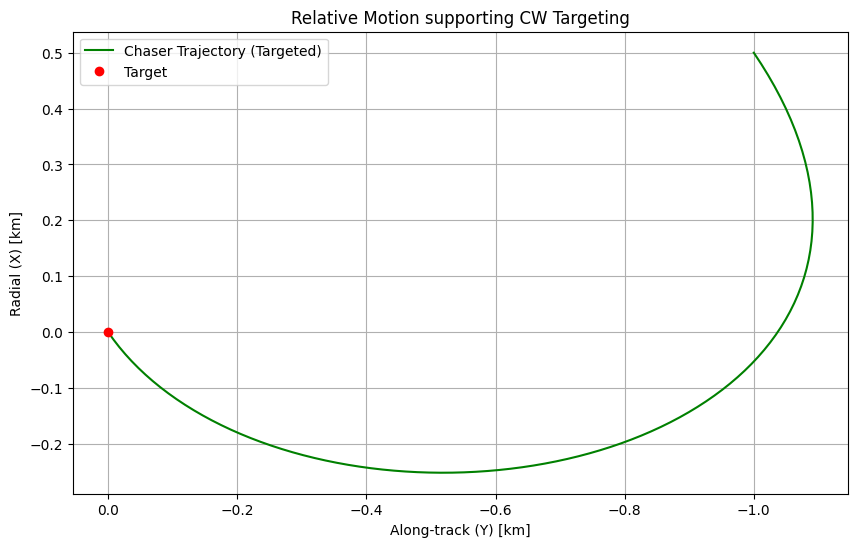

In [8]:
t_transfer = 1800.0  # 30 minutes
r_target = np.array([0.0, 0.0, 0.0])  # Meet the target

v0_req = cw_targeting(r0, r_target, t_transfer, n_orbit)

print(f"Initial Relative Position: {r0} km")
print(f"Required Burn Velocity v0: {v0_req} km/s")
print(f"Delta-V Needed: {np.linalg.norm(v0_req):.6f} km/s")

# Verify by propagating with required v0
r_final, v_final = cw_equations(r0, v0_req, n_orbit, t_transfer)
print(f"\nPosition at t={t_transfer}s: {r_final} km (Should be near [0,0,0])")

# --- Visualization of Targeted Rendezvous ---
time_targeting = np.linspace(0, t_transfer, 100)
history_r_target = []

for t in time_targeting:
    r_t, v_t = cw_equations(r0, v0_req, n_orbit, t)
    history_r_target.append(r_t)
    
history_r_target = np.array(history_r_target)

plt.figure(figsize=(10, 6))
plt.plot(history_r_target[:, 1], history_r_target[:, 0], 'g-', label='Chaser Trajectory (Targeted)')
plt.plot(0, 0, 'ro', label='Target')
plt.xlabel('Along-track (Y) [km]')
plt.ylabel('Radial (X) [km]')
plt.title('Relative Motion supporting CW Targeting')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.show()

## 4. Lambert Solver Targeting

For large absolute separations or higher accuracy, we solve the boundary value problem.

In [9]:
mu = 398600.4418
r1_eci = np.array([7000.0, 0.0, 0.0])  # 7000 km radius
r2_eci = np.array([0.0, 7000.0, 0.0])  # 90-degree phasing
dt_lambert = 1800.0  # 1800 seconds

v1_req, v2_req = solve_lambert(r1_eci, r2_eci, dt_lambert, mu)

print("--- Lambert Solver State ---")
print(f"Required v1 at r1: {v1_req} km/s")
print(f"Required v2 at r2: {v2_req} km/s")
print(f"Energy-like requirement: {np.linalg.norm(v1_req):.4f} km/s v1 depth")

--- Lambert Solver State ---
Required v1 at r1: [1.41321741 6.87245562 0.        ] km/s
Required v2 at r2: [-6.87245562 -1.41321741 -0.        ] km/s
Energy-like requirement: 7.0163 km/s v1 depth
